In [ ]:
pip install pandas matplotlib seaborn numpy openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('Retail Sales & Customer Transactions Summary.xlsx', sheet_name='Sheet1')

print(df.shape)
df.head()

(450, 12)


,Invoice_Code,Client_Code,Item_Name,Department,Units_Sold,Unit_Cost,Discount_Percent,Net_Sales,Shipping_Status,Sales_Representative,Customer_Type,Customer_Rating
0,INV0001,CL5506,LED Monitor,Home Office,6,2324,0,13944.00,Pending,Sneha,Regular,3
1,INV0002,CL9935,Office Chair,Accessories,2,2179,21,3442.82,Delivered,Vikram,Premium,3
2,INV0003,CL2535,LED Monitor,Home Office,4,1020,0,4080.00,Returned,Vikram,Regular,2
3,INV0004,CL4257,Fitness Band,Gadgets,5,10363,0,51815.00,Cancelled,Sneha,Premium,2
4,INV0005,CL4611,Tablet,Accessories,6,9428,13,49214.16,Delivered,Rahul,Regular,1


In [ ]:
print(df.isnull().sum())

print(df.dtypes)

print(f"Duplicate rows: {df.duplicated().sum()}")

Invoice_Code            0
Client_Code             0
Item_Name               0
Department              0
Units_Sold              0
Unit_Cost               0
Discount_Percent        0
Net_Sales               0
Shipping_Status         0
Sales_Representative    0
Customer_Type           0
Customer_Rating         0
dtype: int64
Invoice_Code             object
Client_Code              object
Item_Name                object
Department               object
Units_Sold                int64
Unit_Cost                 int64
Discount_Percent          int64
Net_Sales               float64
Shipping_Status          object
Sales_Representative     object
Customer_Type            object
Customer_Rating           int64
dtype: object
Duplicate rows: 0


In [ ]:
df['Calc_Revenue'] = df['Units_Sold'] * df['Unit_Cost'] * (1 - df['Discount_Percent']/100)

df['Revenue_match'] = np.isclose(df['Calc_Revenue'], df['Net_Sales'], rtol=1e-3)

print(df['Revenue_match'].value_counts())

Revenue_match
True    450
Name: count, dtype: int64


In [ ]:
total_revenue = df['Net_Sales'].sum() / 1000
print(f"Total Revenue: {total_revenue:.2f}K")

Total Revenue: 8971.32K


In [ ]:
total_units = df['Units_Sold'].sum()
print(f"Total Units Sold: {total_units}")

Total Units Sold: 1615


In [ ]:
aov = df['Net_Sales'].mean() / 1000
print(f"AOV: {aov:.2f}K")

AOV: 19.94K


In [ ]:
avg_rating = df['Customer_Rating'].mean()
print(f"Avg Customer Rating: {avg_rating:.1f}")

Avg Customer Rating: 3.0


In [ ]:
ontime_rate = (df['Shipping_Status'] == 'Delivered').mean() * 100
print(f"On-Time Shipping Rate: {ontime_rate:.1f}%")

On-Time Shipping Rate: 24.4%


In [ ]:
avg_discount = df['Discount_Percent'].mean()
print(f"Avg Discount: {avg_discount:.1f}%")

Avg Discount: 13.4%


In [ ]:
dept_revenue = df.groupby('Department')['Net_Sales'].sum().sort_values(ascending=False)
dept_revenue_pct = dept_revenue / total_revenue * 100

print(dept_revenue_pct)

Department
Electronics    19563.129709
Appliances     18220.493449
Gadgets        16074.239736
Fitness        16049.009446
Accessories    15531.502411
Home Office    14561.625249
Name: Net_Sales, dtype: float64


In [ ]:
# Insights

dept_revenue_pct.sort_values().head()

,Net_Sales
Department,
Home Office,14561.625249
Accessories,15531.502411
Fitness,16049.009446
Gadgets,16074.239736
Appliances,18220.493449


In [ ]:
df.groupby('Customer_Type')['Net_Sales'].mean().sort_values(ascending=False)

,Net_Sales
Customer_Type,
Regular,21347.491882
Premium,19195.799718
Wholesale,18959.727681


In [ ]:
df['Gross_Profit'] = df['Net_Sales'] - (df['Units_Sold'] * df['Unit_Cost'])

# Group by discount buckets
df['Discount_Bucket'] = pd.cut(df['Discount_Percent'], bins=[0,5,10,15,20,25], labels=['0-5%','5-10%','10-15%','15-20%','20-25%'])

discount_profit = df.groupby('Discount_Bucket')['Gross_Profit'].mean()
print(discount_profit)

Discount_Bucket
0-5%      -679.191389
5-10%    -1868.145000
10-15%   -2671.657500
15-20%   -4296.972283
20-25%   -5254.946346
Name: Gross_Profit, dtype: float64


/tmp/ipykernel_1657/2427168524.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_profit = df.groupby('Discount_Bucket')['Gross_Profit'].mean()


In [ ]:
# Repeat purchase: count invoices per client
repeat = df.groupby('Client_Code').size().reset_index(name='Order_Count')
df_with_repeat = df.merge(repeat, on='Client_Code')

rating_repeat = df_with_repeat.groupby('Customer_Rating')['Order_Count'].mean()
print(rating_repeat)

Customer_Rating
1    1.011628
2    1.011364
3    1.030928
4    1.010417
5    1.024096
Name: Order_Count, dtype: float64


In [ ]:
top_items = df.groupby('Item_Name')['Net_Sales'].sum().sort_values(ascending=False).head(10)
print(top_items)

Item_Name
Tablet               1072411.12
Office Chair          867498.83
Wireless Mouse        861248.60
Gaming Keyboard       773707.81
Air Purifier          769994.25
Fitness Band          767756.01
Smartphone            730022.77
Bluetooth Speaker     700504.97
Coffee Maker          688341.21
Desk Lamp             622459.83
Name: Net_Sales, dtype: float64


In [ ]:
pd.crosstab(df['Customer_Type'], df['Shipping_Status'], normalize='index')

Shipping_Status,Cancelled,Delivered,Pending,Returned
Customer_Type,,,,
Premium,0.232394,0.246479,0.239437,0.28169
Regular,0.182353,0.282353,0.235294,0.30000
Wholesale,0.289855,0.195652,0.253623,0.26087


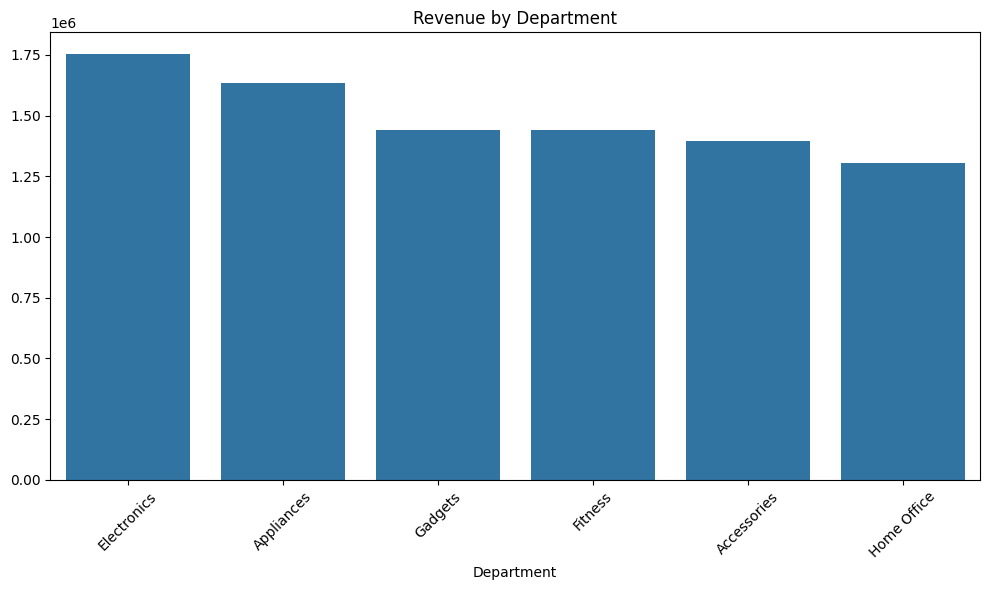

In [ ]:
# 1. Revenue by department
plt.figure(figsize=(10,6))
sns.barplot(x=dept_revenue.index, y=dept_revenue.values)
plt.title('Revenue by Department')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('revenue_by_dept.png')

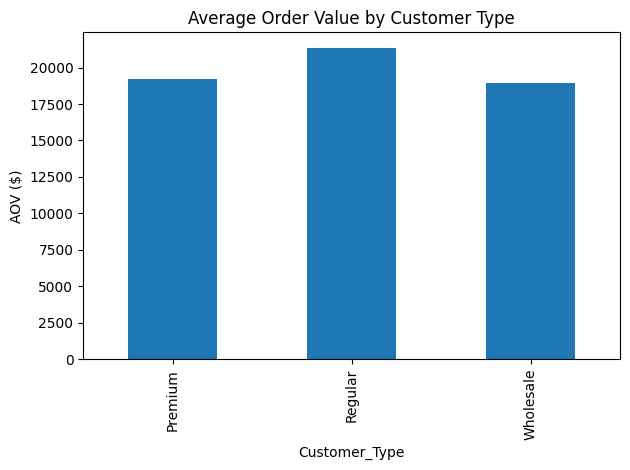

In [ ]:
# 2. AOV by customer type
aov_by_type = df.groupby('Customer_Type')['Net_Sales'].mean()
plt.figure()
aov_by_type.plot(kind='bar')
plt.title('Average Order Value by Customer Type')
plt.ylabel('AOV ($)')
plt.tight_layout()
plt.savefig('aov_by_type.png')

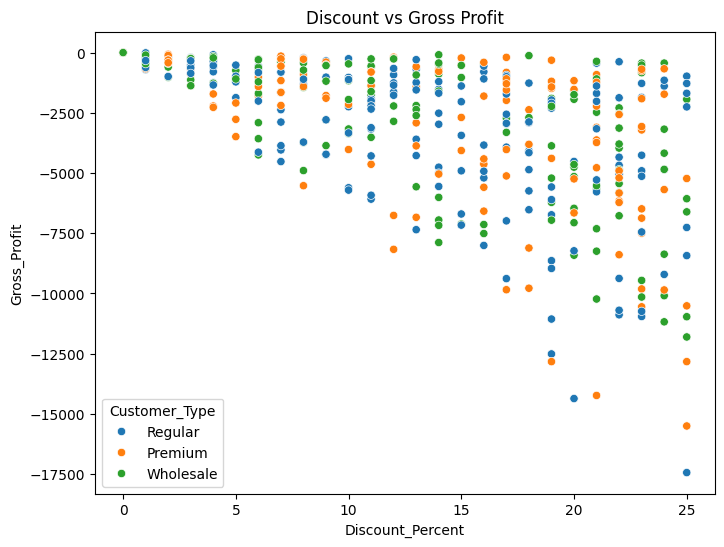

In [ ]:
# 3. Discount vs Gross Profit scatter
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Discount_Percent', y='Gross_Profit', hue='Customer_Type')
plt.title('Discount vs Gross Profit')
plt.savefig('discount_profit_scatter.png')

#requirements.txt`

In [ ]:
requirements = [
    'pandas',
    'matplotlib',
    'seaborn',
    'numpy',
    'openpyxl'
]

with open('requirements.txt', 'w') as f:
    for req in requirements:
        f.write(req + '\n')

print('requirements.txt created successfully.')